# Anaerobic Digestion of Olive Mill Waste
## Data-Driven Modelling - Database Generation
### Crete, Greece Case Study

This notebook generates the complete project database used to train ANN, RNN, and LSTM models
in PyTorch. It covers:

1. The ODE model definition and parameter sources
2. Running all 36 simulations
3. Inspecting the base dataset
4. Data augmentation (noise replication ×25)
5. Saving the full Excel database

**Output:** `olive_mill_AD_database.xlsx` with 4 sheets:
- `README` : variable definitions, parameters, sources
- `RAW_SIMULATION` : 1,080 rows of clean ODE output
- `STANDARDISATION_REF` : 1,080 rows in 8-column model format (for scaler fitting)
- `PREPARED_TRAINING` ; 27,000 rows noise-augmented and shuffled (for PyTorch)

---
**References:**
- Borja et al. (2003) — Biochemical Engineering Journal 15(2–3), 107–115
- Keating et al. (2016) — PMC4875066
- Federici et al. (2020) — J. Applied Phycology 32
- Hamdi (1999) — Process Biochemistry 34(3)


## 1. Imports

install any missing packages with `pip install scipy numpy openpyxl matplotlib`.

In [12]:
pip install scipy numpy openpyxl matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 10.1 MB/s  0:00:01eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import odeint
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

print("All imports successful.")
print(f"  numpy  version: {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


All imports successful.
  numpy  version: 2.4.4


## 2. ODE Model — Kinetic Parameters

the digestion process is described by 3 coupled ODEs.
the parameters below directly from the literature:

| Parameter | Value | Units | Source |
|-----------|-------|-------|--------|
| k_h | 0.08 | 1/day | Keating et al. (2016) — hydrolysis rate for OMSW |
| Y_CH4 | 380 | mL CH₄/g VS | Federici et al. (2020) — methane yield from OMSW batch tests |
| k_pH | 0.005 | pH/(g VS·day) | Engineering estimate — calibrated to mesophilic range |
| S_ref | 2.0 | g VS/L | Residual non-degradable VS fraction |


In [ ]:
# ─── Kinetic parameters ───────────────────────────────────────────────────────

k_h   = 0.08    # hydrolysis rate constant (1/day)
                # first-order: rate of VS breakdown proportional to remaining VS
                # source: Keating et al. (2016) PMC4875066

Y_CH4 = 380.0   # methane yield (mL CH4 per gram VS consumed)
                # source: Federici et al. (2020) J. Applied Phycology

k_pH  = 0.003   # acidification rate constant
                # controls how fast pH drops as organic acids accumulate

S_ref = 2.0     # equilibrium (residual) volatile solids (g VS/L)
                # represents non-degradable fraction remaining in digester

pH_eq = 6.8     # bicarbonate buffer floor (pH units)
                # minimum pH sustained by alkalinity buffering in mesophilic digesters
                # source: Borja et al. (2003) — stable OMSW operation at pH 6.8-7.4
                # replaces full alkalinity balance from ADM1 (Batstone et al. 2002)

print("Parameters loaded:")
print(f"  k_h   = {k_h}  /day")
print(f"  Y_CH4 = {Y_CH4}  mL CH4/g VS")
print(f"  k_pH  = {k_pH}")
print(f"  S_ref = {S_ref}  g VS/L")
print(f"  pH_eq = {pH_eq}  (buffer floor)")

Parameters loaded:
  k_h   = 0.08  /day
  Y_CH4 = 380.0  mL CH4/g VS
  k_pH  = 0.003
  S_ref = 2.0  g VS/L
  pH_eq = 6.8  (buffer floor)


## 3. Correction Functions

2 functions scale the reaction rates based on operating conditions:

**Temperature correction f_T(T):**
uses a simplified Arrhenius form. Equal to 1.0 at 35°C (optimum), decreasing above and below.

**pH inhibition f_pH(pH):**
sigmoidal function. near 1.0 at neutral pH, drops fastly below pH 6.5,
approaching 0 at pH < 6.0. this represents the sensitivity of methanogens to acidic conditions.


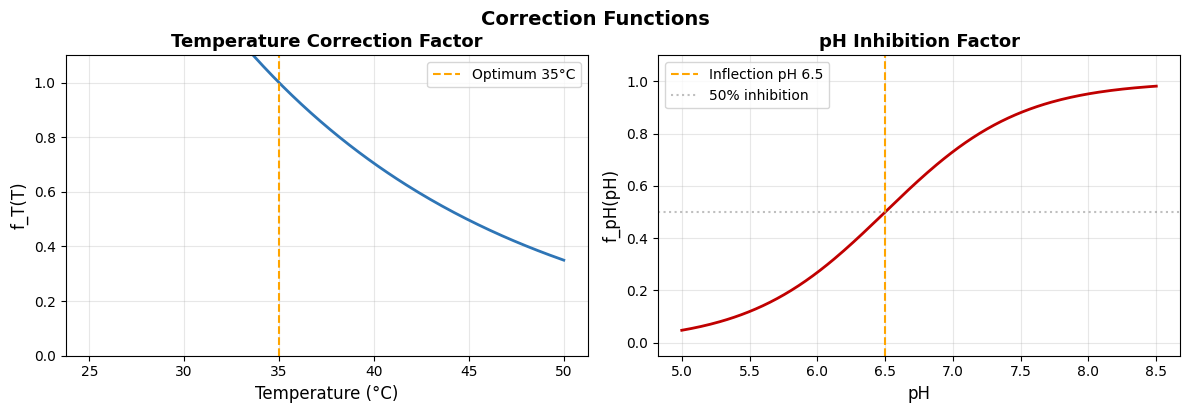

f_T at 30°C: 1.419
f_T at 35°C: 1.0
f_T at 42°C: 0.613

f_pH at pH 7.4: 0.858
f_pH at pH 6.5: 0.5
f_pH at pH 6.0: 0.269


In [ ]:
def temperature_correction(T):
    """
    temperature correction factor f_T
    simplified Arrhenius form — optimum at 35°C
    
    parameters
    ----------
    T : float
        operating temperature (°C)
    
    returns
    -------
    float
        dimensionless correction factor (0 to 1)
    """
    return np.exp(-0.07 * (T - 35.0))


def pH_inhibition(pH):
    """
    pH inhibition function f_pH
    sigmoidal : approaches 1 above pH 7, drops to 0 below pH 6
    represents methanogen sensitivity to acidic conditions
    
    parameters
    ----------
    pH : float
        current digester pH
        
    returns
    -------
    float
        dimensionless inhibition factor (0 to 1)
    """
    return 1.0 / (1.0 + np.exp(-2.0 * (pH - 6.5)))


# ─── plot correction functions to verify their shape ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

T_range  = np.linspace(25, 50, 200)
pH_range = np.linspace(5.0, 8.5, 200)

axes[0].plot(T_range, temperature_correction(T_range), color='#2E75B6', linewidth=2)
axes[0].axvline(35, color='orange', linestyle='--', label='Optimum 35°C')
axes[0].set_xlabel('Temperature (°C)', fontsize=12)
axes[0].set_ylabel('f_T(T)', fontsize=12)
axes[0].set_title('Temperature Correction Factor', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.1)

axes[1].plot(pH_range, pH_inhibition(pH_range), color='#C00000', linewidth=2)
axes[1].axvline(6.5, color='orange', linestyle='--', label='Inflection pH 6.5')
axes[1].axhline(0.5, color='grey', linestyle=':', alpha=0.5, label='50% inhibition')
axes[1].set_xlabel('pH', fontsize=12)
axes[1].set_ylabel('f_pH(pH)', fontsize=12)
axes[1].set_title('pH Inhibition Factor', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.suptitle('Correction Functions', fontsize=14, fontweight='bold', y=1.02)
plt.show()
print("f_T at 30°C:", round(temperature_correction(30), 3))
print("f_T at 35°C:", round(temperature_correction(35), 3))
print("f_T at 42°C:", round(temperature_correction(42), 3))
print()
print("f_pH at pH 7.4:", round(pH_inhibition(7.4), 3))
print("f_pH at pH 6.5:", round(pH_inhibition(6.5), 3))
print("f_pH at pH 6.0:", round(pH_inhibition(6.0), 3))

## 4. ODE System Definition

the 3 equations:

```
dS/dt  = −k_h × S × f_T(T) × f_pH(pH)      volatile solids consumption
dM/dt  =  Y_CH4 × k_h × S × f_T(T) × f_pH(pH)   methane production
dpH/dt = −k_pH × max(S − S_ref, 0)          pH acidification
```

**State variables:**
- **S** = volatile solids (g VS/L) : organic matter remaining
- **M** = methane production rate (mL CH₄/L/day)
- **pH** = digester acidity

**Inputs held constant within each run:**
- **T** = temperature (°C)
- **OLR** = organic loading rate (g VS/L/day)


In [ ]:
def digester_ode(state, t, T, OLR):
    """
    ODE system for anaerobic digestion of olive mill waste.
    Called by scipy.integrate.odeint at each integration timestep.
    
    Parameters
    ----------
    state : list [S, M, pH]
        Current state of the digester
    t : float
        Current time in days (required by odeint, not used directly)
    T : float
        Operating temperature (°C) : constant within a run
    OLR : float
        Organic loading rate (g VS/L/day) : constant within a run
    
    Returns
    -------
    list [dS/dt, dM/dt, dpH/dt]
        Rates of change of each state variable
    """
    S, M, pH = state
    S = max(S, 0.0)   # numerical safety: prevent negative VS

    # Shared consumption rate term (appears in both VS and methane equations)
    consumption_rate = k_h * S * temperature_correction(T) * pH_inhibition(pH)

    dS_dt  = -consumption_rate                  # VS decreases as bacteria consume it
    dM_dt  =  Y_CH4 * consumption_rate          # methane produced proportional to VS consumed
    pH = max(pH, pH_eq)                         # buffering: pH cannot drop below bicarbonate equilibrium
    dpH_dt = -k_pH * max(S - S_ref, 0.0) * (pH - pH_eq)

    return [dS_dt, dM_dt, dpH_dt]

print("ODE function defined successfully.")

ODE function defined successfully.


## 5. Single Run Demo

before running the 36 simulations, solve first the ODE for one set of conditions
and plot the result to make sure the model behaves correctly


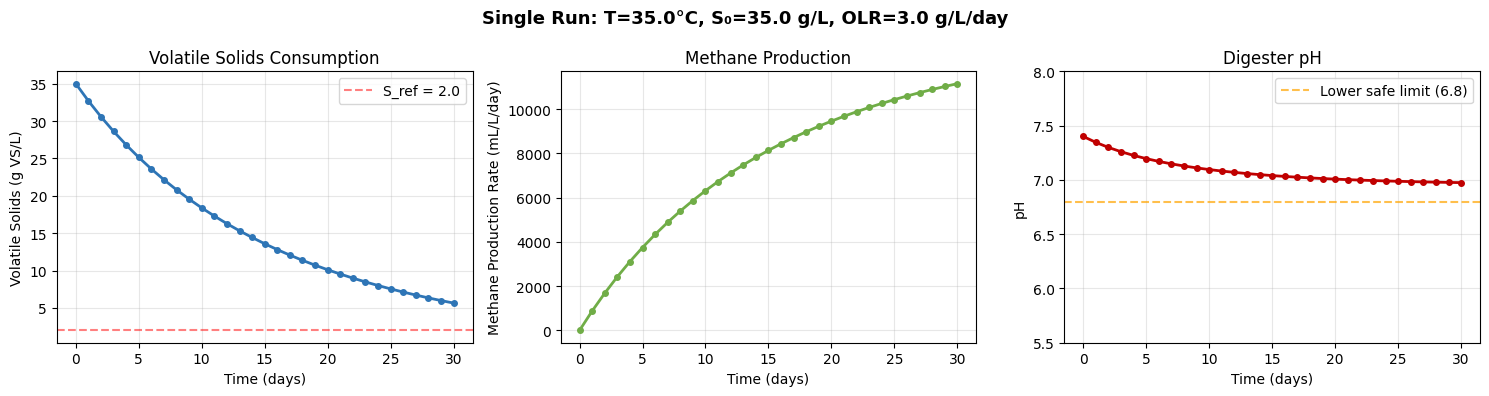

Day 0:  S=35.00 g/L,  M=0.00 mL/L/day,  pH=7.400
Day 15: S=13.59 g/L, M=8136.07 mL/L/day, pH=7.040
Day 30: S=5.65 g/L, M=11151.66 mL/L/day, pH=6.975


In [ ]:
# ─── demo: single run at T=35°C, S0=35 g/L, OLR=3 g/L/day ──────────────────
T_demo   = 35.0
S0_demo  = 35.0
OLR_demo = 3.0
pH0      = 7.4

t_span   = np.linspace(0, 30, 31)   # 0 to 30 days
y0_demo  = [S0_demo, 0.0, pH0]

sol_demo = odeint(digester_ode, y0_demo, t_span, args=(T_demo, OLR_demo))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t_span, sol_demo[:, 0], color='#2E75B6', linewidth=2, marker='o', markersize=4)
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Volatile Solids (g VS/L)')
axes[0].set_title('Volatile Solids Consumption')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(S_ref, color='red', linestyle='--', alpha=0.5, label=f'S_ref = {S_ref}')
axes[0].legend()

axes[1].plot(t_span, sol_demo[:, 1], color='#70AD47', linewidth=2, marker='o', markersize=4)
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Methane Production Rate (mL/L/day)')
axes[1].set_title('Methane Production')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_span, sol_demo[:, 2], color='#C00000', linewidth=2, marker='o', markersize=4)
axes[2].set_xlabel('Time (days)')
axes[2].set_ylabel('pH')
axes[2].set_title('Digester pH')
axes[2].set_ylim(5.5, 8.0)
axes[2].axhline(6.8, color='orange', linestyle='--', alpha=0.7, label='Lower safe limit (6.8)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Single Run: T={T_demo}°C, S₀={S0_demo} g/L, OLR={OLR_demo} g/L/day',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Day 0:  S={sol_demo[0,0]:.2f} g/L,  M={sol_demo[0,1]:.2f} mL/L/day,  pH={sol_demo[0,2]:.3f}")
print(f"Day 15: S={sol_demo[15,0]:.2f} g/L, M={sol_demo[15,1]:.2f} mL/L/day, pH={sol_demo[15,2]:.3f}")
print(f"Day 30: S={sol_demo[30,0]:.2f} g/L, M={sol_demo[30,1]:.2f} mL/L/day, pH={sol_demo[30,2]:.3f}")

## 6. Simulation Conditions

all combinations of the parameters below are simulated.
**4 temperatures × 3 initial VS levels × 3 OLR values = 36 runs total**

| Parameter | Values | Source |
|-----------|--------|--------|
| temperature | 30, 35, 38, 42 °C | full mesophilic range — Borja et al. (2003) |
| initial VS (S₀) | 15, 35, 55 g VS/L | corresponds to 34.5, 81.1, 113 g COD/L — Borja et al. (2003) |
| OLR | 1, 3, 6 g VS/L/day | stable operating range for OMSW — Hamdi (1999) |
| initial pH | 7.4 (fixed) | typical mesophilic digester startup |
| time span | 0 to 30 days (daily) | sufficient for near-complete degradation |


In [ ]:
# ─── simulation grid ──────────────────────────────────────────────────────────
temperatures = [30.0, 35.0, 38.0, 42.0]   # °C
initial_VS   = [15.0, 35.0, 55.0]         # g VS/L
olr_values   = [1.0,  3.0,  6.0]          # g VS/L/day

initial_pH   = 7.4                         # fixed starting pH
t_span       = np.linspace(0, 30, 31)      # 31 points = 30 daily intervals

total_runs = len(temperatures) * len(initial_VS) * len(olr_values)
print(f"Total simulation runs: {total_runs}")
print(f"  Temperatures : {temperatures}")
print(f"  Initial VS   : {initial_VS}")
print(f"  OLR values   : {olr_values}")
print(f"  Time span    : day 0 to day 30 (daily timesteps)")
print(f"  Rows per run : {len(t_span) - 1}")
print(f"  Total rows   : {total_runs * (len(t_span) - 1)}")

Total simulation runs: 36
  Temperatures : [30.0, 35.0, 38.0, 42.0]
  Initial VS   : [15.0, 35.0, 55.0]
  OLR values   : [1.0, 3.0, 6.0]
  Time span    : day 0 to day 30 (daily timesteps)
  Rows per run : 30
  Total rows   : 1080


## 7. Run All 36 Simulations

ok now loop over every combination, solve the ODE, and compute the rates of change
as finite differences between consecutive timesteps


In [34]:
all_runs = []
run_id   = 0

for T in temperatures:
    for S0 in initial_VS:
        for OLR in olr_values:

            run_id += 1
            y0       = [S0, 0.0, initial_pH]

            # Solve ODE numerically — returns array shape (31, 3)
            solution = odeint(digester_ode, y0, t_span, args=(T, OLR))

            # Extract rows: state at timestep i + rate of change i→i+1
            for i in range(len(t_span) - 1):

                S_now  = solution[i, 0]
                M_now  = solution[i, 1]
                pH_now = solution[i, 2]

                # Rate = (next value - current value) / Δt  where Δt = 1 day
                dS_dt  = solution[i+1, 0] - solution[i, 0]
                dM_dt  = solution[i+1, 1] - solution[i, 1]
                dpH_dt = solution[i+1, 2] - solution[i, 2]

                all_runs.append({
                    # metadata
                    'run_id'    : run_id,
                    'T_C'       : round(T,   1),
                    'S0_gVS_L'  : round(S0,  1),
                    'OLR'       : round(OLR, 1),
                    'day'       : int(t_span[i]),
                    # inputs
                    'S_gVS_L'   : round(max(S_now,  0.0), 4),
                    'M_mL_L_day': round(max(M_now,  0.0), 4),
                    'pH'        : round(pH_now,           4),
                    # targets
                    'dS_dt'     : round(dS_dt,  6),
                    'dM_dt'     : round(dM_dt,  6),
                    'dpH_dt'    : round(dpH_dt, 6),
                })

print(f"Simulations complete.")
print(f"  Runs completed : {run_id}")
print(f"  Total rows     : {len(all_runs)}")

Simulations complete.
  Runs completed : 36
  Total rows     : 1080


## 8. Inspect the Base Dataset

plot all 36 trajectories together to see the spread of the data across conditions


In [35]:
import pandas as pd

df = pd.DataFrame(all_runs)
print("Dataset shape:", df.shape)
print()
print(df.describe().round(3))

Dataset shape: (1080, 11)

         run_id       T_C  S0_gVS_L       OLR       day   S_gVS_L  M_mL_L_day  \
count  1080.000  1080.000  1080.000  1080.000  1080.000  1080.000    1080.000   
mean     18.500    36.250    35.000     3.333    14.500    17.244    6747.284   
std      10.393     4.382    16.337     2.056     8.659    12.588    4704.473   
min       1.000    30.000    15.000     1.000     0.000     0.989       0.000   
25%       9.750    33.750    15.000     1.000     7.000     7.265    3122.429   
50%      18.500    36.500    35.000     3.000    14.500    13.705    5306.064   
75%      27.250    39.000    55.000     6.000    22.000    24.551   10023.703   
max      36.000    42.000    55.000     6.000    29.000    55.000   19051.904   

             pH     dS_dt     dM_dt    dpH_dt  
count  1080.000  1080.000  1080.000  1080.000  
mean      7.109    -0.928   352.734    -0.013  
std       0.156     0.755   286.819     0.016  
min       6.837    -5.042    33.322    -0.086  
25%

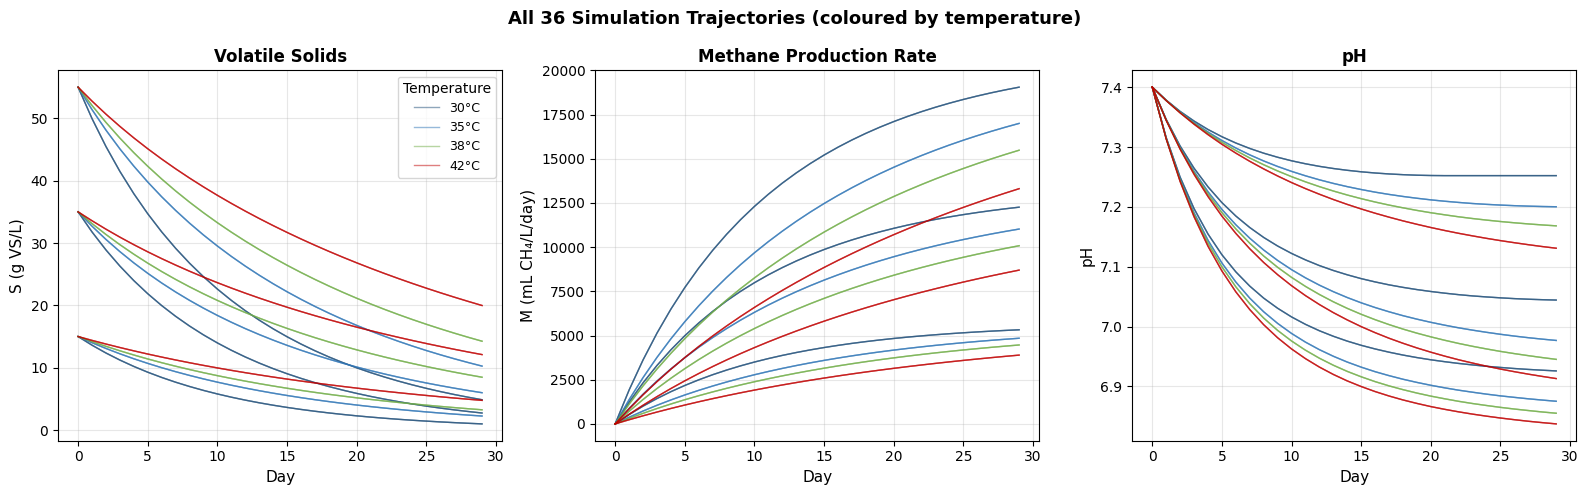

In [ ]:
# ─── plot all trajectories ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {30.0: '#1F4E79', 35.0: '#2E75B6', 38.0: '#70AD47', 42.0: '#C00000'}
labels = {30.0: '30°C', 35.0: '35°C', 38.0: '38°C', 42.0: '42°C'}

plotted = set()
for _, group in df.groupby(['run_id', 'T_C', 'S0_gVS_L', 'OLR']):
    T_val = group['T_C'].iloc[0]
    color = colors[T_val]
    label = labels[T_val] if T_val not in plotted else '_nolegend_'
    plotted.add(T_val)

    axes[0].plot(group['day'], group['S_gVS_L'],    color=color, alpha=0.5, linewidth=1, label=label)
    axes[1].plot(group['day'], group['M_mL_L_day'], color=color, alpha=0.5, linewidth=1, label='_nolegend_')
    axes[2].plot(group['day'], group['pH'],          color=color, alpha=0.5, linewidth=1, label='_nolegend_')

for ax, title, ylabel in zip(axes,
    ['Volatile Solids', 'Methane Production Rate', 'pH'],
    ['S (g VS/L)', 'M (mL CH₄/L/day)', 'pH']):
    ax.set_xlabel('Day', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[0].legend(title='Temperature', fontsize=9)
plt.suptitle('All 36 Simulation Trajectories (coloured by temperature)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Rate of Change Distributions

the nn predicts dS/dt, dM/dt, and dpH/dt - check their distributions before training


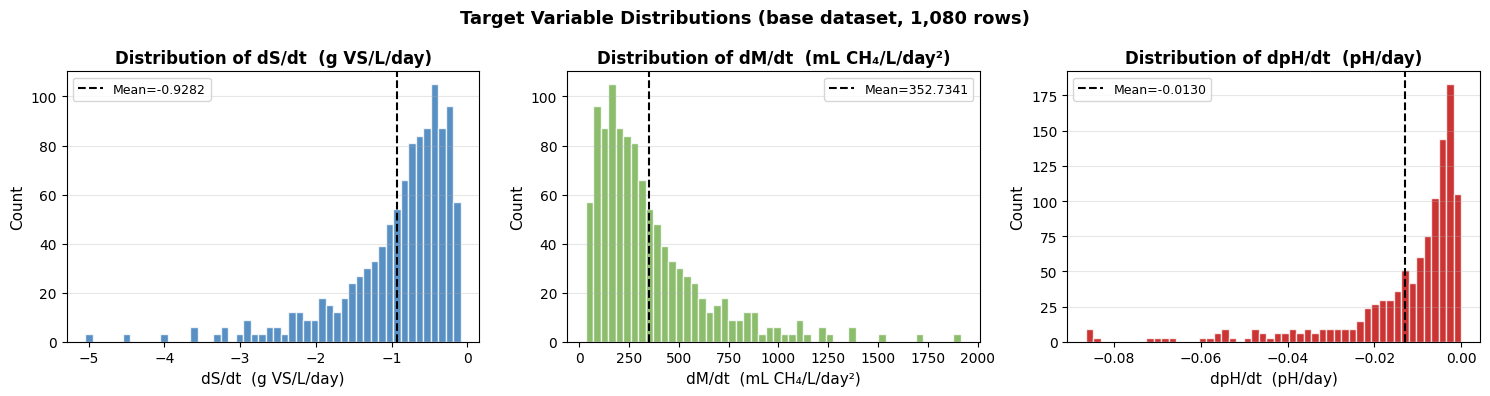

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title, color in zip(
    axes,
    ['dS_dt', 'dM_dt', 'dpH_dt'],
    ['dS/dt  (g VS/L/day)', 'dM/dt  (mL CH₄/L/day²)', 'dpH/dt  (pH/day)'],
    ['#2E75B6', '#70AD47', '#C00000']
):
    ax.hist(df[col], bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'Distribution of {title}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean={df[col].mean():.4f}')
    ax.legend(fontsize=9)

plt.suptitle('Target Variable Distributions (base dataset, 1,080 rows)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Data Augmentation

1,080 rows is too small for nn training. to tackle that we replicated each row **25 times** with gaussian noise:

```
x_noisy = Normal(mean = x_clean,  std = |x_clean| × σ)
σ = 0.05 × 0.333 = 0.01667
```

this mimics typical measurement uncertainty in lab-scale digesters (~5%).
the 27,000 rows are then shuffled so the model doesn't see all 25 copies of the same run consecutively

the StandardScaler is fitted on the **clean 1,080 rows only** (NOT on the noisy data)


In [ ]:
NOISE_LEVEL  = 0.05 * 0.333   # 5% measurement uncertainty ÷ 3σ = 1.67%
REPLICATIONS = 25
RANDOM_SEED  = 42

np.random.seed(RANDOM_SEED)

# build the 8-column arrays for scaler reference and training
# column order: S, M, pH, T, OLR, dS/dt, dM/dt, dpH/dt
def row_to_array(r):
    return np.array([
        r['S_gVS_L'], r['M_mL_L_day'], r['pH'],
        r['T_C'], r['OLR'],
        r['dS_dt'], r['dM_dt'], r['dpH_dt']
    ])

# STANDARDISATION_REF: clean rows only (no noise)
std_ref_data = np.array([row_to_array(r) for r in all_runs])
print(f"STANDARDISATION_REF shape: {std_ref_data.shape}")

# PREPARED_TRAINING: 25 noisy copies per row, shuffled
augmented = []
for r in all_runs:
    base = row_to_array(r)
    for _ in range(REPLICATIONS):
        noisy = np.random.normal(
            loc   = base,
            scale = np.abs(base) * NOISE_LEVEL + 1e-6
        )
        augmented.append(noisy)

augmented = np.array(augmented)
np.random.shuffle(augmented)   # in-place shuffle of rows
print(f"PREPARED_TRAINING shape:   {augmented.shape}")
print()
print(f"Noise level (σ): {NOISE_LEVEL:.4f}  ({NOISE_LEVEL*100:.2f}% of each value)")
print(f"Random seed    : {RANDOM_SEED}  (fixed for reproducibility)")

STANDARDISATION_REF shape: (1080, 8)
PREPARED_TRAINING shape:   (27000, 8)

Noise level (σ): 0.0167  (1.67% of each value)
Random seed    : 42  (fixed for reproducibility)


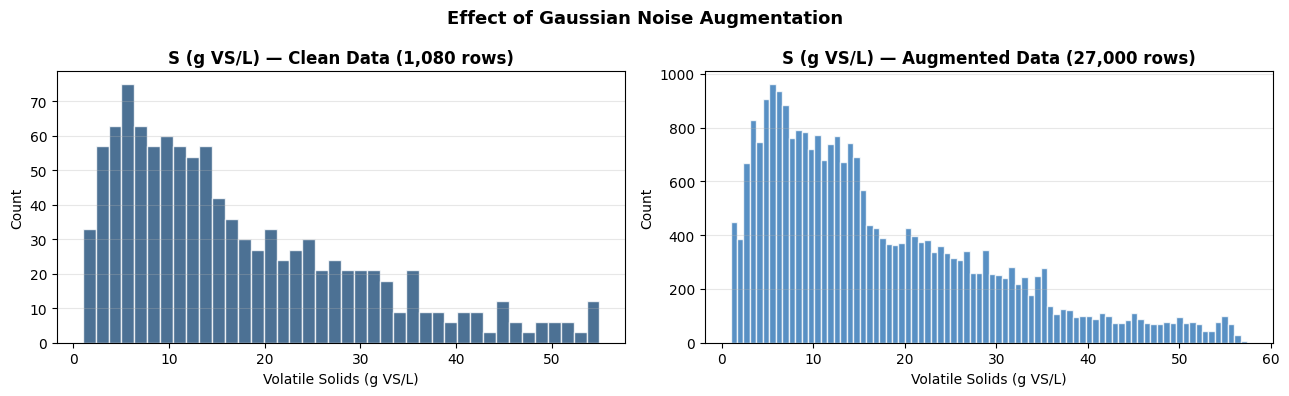

In [ ]:
# ─── visualise the effect of noise augmentation ───────────────────────────────
# compare clean vs noisy distributions for volatile solids (column 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(std_ref_data[:, 0], bins=40, color='#1F4E79', alpha=0.8, edgecolor='white')
axes[0].set_title('S (g VS/L) — Clean Data (1,080 rows)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Volatile Solids (g VS/L)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].hist(augmented[:, 0], bins=80, color='#2E75B6', alpha=0.8, edgecolor='white')
axes[1].set_title('S (g VS/L) — Augmented Data (27,000 rows)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Volatile Solids (g VS/L)')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Effect of Gaussian Noise Augmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Write the Excel Database

all 4 sheets are written to `olive_mill_AD_database.xlsx`.


In [ ]:
# ─── style definitions ────────────────────────────────────────────────────────
BLUE_DARK  = '1F4E79'
BLUE_MID   = '2E75B6'
BLUE_LIGHT = 'D5E8F0'
BLUE_PALE  = 'EBF3FB'

header_font  = Font(name='Arial', bold=True,   size=10, color='FFFFFF')
header_fill  = PatternFill('solid', fgColor=BLUE_DARK)
desc_font    = Font(name='Arial', italic=True, size=9,  color=BLUE_DARK)
desc_fill    = PatternFill('solid', fgColor=BLUE_LIGHT)
data_font    = Font(name='Arial',              size=9)
alt_fill     = PatternFill('solid', fgColor=BLUE_PALE)
section_font = Font(name='Arial', bold=True,   size=11, color=BLUE_DARK)
label_font   = Font(name='Arial', bold=True,   size=10)
body_font    = Font(name='Arial',              size=10)
title_font   = Font(name='Arial', bold=True,   size=13, color='FFFFFF')
title_fill   = PatternFill('solid', fgColor=BLUE_MID)


def write_data_sheet(ws, col_headers, col_descriptions, col_widths, data_rows):
    """Write a formatted data sheet with two-row header and alternating row colours."""
    for ci, w in enumerate(col_widths, 1):
        ws.column_dimensions[get_column_letter(ci)].width = w

    for ci, h in enumerate(col_headers, 1):
        c = ws.cell(row=1, column=ci, value=h)
        c.font = header_font;  c.fill = header_fill
        c.alignment = Alignment(horizontal='center', vertical='center')

    for ci, d in enumerate(col_descriptions, 1):
        c = ws.cell(row=2, column=ci, value=d)
        c.font = desc_font;  c.fill = desc_fill
        c.alignment = Alignment(horizontal='center', wrap_text=True)

    ws.row_dimensions[1].height = 16
    ws.row_dimensions[2].height = 28
    ws.freeze_panes = 'A3'

    for ri, row in enumerate(data_rows, start=3):
        fill = alt_fill if ri % 2 == 0 else None
        for ci, v in enumerate(row, 1):
            c = ws.cell(row=ri, column=ci, value=v)
            c.font = data_font
            c.alignment = Alignment(horizontal='center')
            if fill:
                c.fill = fill

print("Style definitions ready.")

Style definitions ready.


In [41]:
wb = openpyxl.Workbook()

# ─── Sheet 1: README ─────────────────────────────────────────────────────────
ws_readme = wb.active
ws_readme.title = 'README'
ws_readme.column_dimensions['A'].width = 30
ws_readme.column_dimensions['B'].width = 68

readme_content = [
    ('TITLE',   'Anaerobic Digestion of Olive Mill Waste — Project Database', ''),
    ('BLANK',   '', ''),
    ('SECTION', 'PURPOSE', ''),
    ('BODY',    'This workbook is the formal data repository for the olive mill waste', ''),
    ('BODY',    'anaerobic digestion modelling project. All data used for training ANN,', ''),
    ('BODY',    'RNN, and LSTM models in PyTorch is sourced from this file.', ''),
    ('BLANK',   '', ''),
    ('SECTION', 'SHEET GUIDE', ''),
    ('KV', 'README',              'This sheet — variable definitions, parameters, sources'),
    ('KV', 'RAW_SIMULATION',      '1,080 rows: ODE output with run metadata'),
    ('KV', 'STANDARDISATION_REF', '1,080 rows: 8-column format for fitting StandardScaler'),
    ('KV', 'PREPARED_TRAINING',   '27,000 rows: noise-augmented training data for PyTorch'),
    ('BLANK',   '', ''),
    ('SECTION', 'INPUT VARIABLES (columns 1-5)', ''),
    ('KV', 'S  [g VS/L]',       'Volatile solids — organic matter remaining in digester'),
    ('KV', 'M  [mL CH4/L/day]', 'Methane production rate at current timestep'),
    ('KV', 'pH [-]',            'Digester pH (optimal 6.8-7.5 for methanogenesis)'),
    ('KV', 'T  [°C]',           'Operating temperature — mesophilic range 30-42°C'),
    ('KV', 'OLR [g VS/L/day]',  'Organic loading rate — fresh feed of olive mill waste'),
    ('BLANK', '', ''),
    ('SECTION', 'OUTPUT VARIABLES (columns 6-8)', ''),
    ('KV', 'dS/dt  [g VS/L/day]',  'Rate of change of volatile solids (negative)'),
    ('KV', 'dM/dt  [mL/L/day2]',   'Rate of change of methane production rate'),
    ('KV', 'dpH/dt [pH/day]',      'Rate of change of pH (negative = acidification)'),
    ('BLANK', '', ''),
    ('SECTION', 'KINETIC PARAMETERS', ''),
    ('KV', 'k_h  = 0.08 /day',           'Keating et al. (2016) PMC4875066'),
    ('KV', 'Y_CH4 = 380 mL/g VS',        'Federici et al. (2020) J. Applied Phycology'),
    ('KV', 'k_pH = 0.005',               'Engineering estimate'),
    ('KV', 'S_ref = 2.0 g/L',            'Residual VS at equilibrium'),
    ('KV', 'f_T = exp(-0.07*(T-35))',    'Borja et al. (2003)'),
    ('KV', 'f_pH = 1/(1+exp(-2*(pH-6.5)))', 'Standard sigmoidal inhibition'),
    ('BLANK', '', ''),
    ('SECTION', 'DATA AUGMENTATION', ''),
    ('KV', 'Replications', '25 noisy copies per base row'),
    ('KV', 'Noise sigma',  '0.05 x 0.333 = 1.67% of each value (Gaussian)'),
    ('KV', 'Total rows',   '1,080 x 25 = 27,000 training rows'),
    ('KV', 'Scaler',       'StandardScaler fitted on STANDARDISATION_REF only'),
    ('BLANK', '', ''),
    ('SECTION', 'REFERENCES', ''),
    ('KV', '[1] Borja et al. (2003)',    'Biochemical Engineering Journal 15(2-3), 107-115'),
    ('KV', '[2] Keating et al. (2016)', 'PMC4875066 — simplified AD kinetic models'),
    ('KV', '[3] Federici et al. (2020)','J. Applied Phycology 32 — OMSW methane yield'),
    ('KV', '[4] Hamdi (1999)',           'Process Biochemistry 34(3) — OMSW OLR range'),
]

for row_i, row_data in enumerate(readme_content, start=1):
    rtype = row_data[0]; col_a = row_data[1]; col_b = row_data[2] if len(row_data) > 2 else ''
    ca = ws_readme.cell(row=row_i, column=1, value=col_a)
    cb = ws_readme.cell(row=row_i, column=2, value=col_b)
    if rtype == 'TITLE':
        ws_readme.row_dimensions[row_i].height = 22
        for c in [ca, cb]: c.font = title_font; c.fill = title_fill; c.alignment = Alignment(vertical='center')
        ws_readme.merge_cells(f'A{row_i}:B{row_i}')
    elif rtype == 'SECTION':
        ca.font = section_font
        ca.border = Border(bottom=Side(style='medium', color=BLUE_MID))
        ws_readme.row_dimensions[row_i].height = 18
        ws_readme.merge_cells(f'A{row_i}:B{row_i}')
    elif rtype == 'KV':
        ca.font = label_font; cb.font = body_font
        ca.alignment = Alignment(wrap_text=True, vertical='top')
        cb.alignment = Alignment(wrap_text=True, vertical='top')
    elif rtype == 'BODY':
        ca.font = body_font
        ws_readme.merge_cells(f'A{row_i}:B{row_i}')
        ca.alignment = Alignment(wrap_text=True)
    elif rtype == 'BLANK':
        ws_readme.row_dimensions[row_i].height = 6

print("README sheet written.")

README sheet written.


In [ ]:
# ─── sheet 2: RAW_SIMULATION ─────────────────────────────────────────────────
ws_raw = wb.create_sheet('RAW_SIMULATION')

raw_headers = ['run_id','T_C','S0_gVS_L','OLR_gVS_L_day','day',
               'S_gVS_L','M_mL_L_day','pH','dS_dt','dM_dt','dpH_dt']
raw_descs   = ['Run ID','Temp (°C)','Initial VS (g/L)','OLR (g/L/day)','Day (0-29)',
               'Vol. Solids (g/L)','Methane Rate (mL/L/day)','pH',
               'dS/dt','dM/dt','dpH/dt']
raw_widths  = [9,10,14,16,8,18,20,10,16,16,16]
raw_rows    = [[r['run_id'],r['T_C'],r['S0_gVS_L'],r['OLR'],r['day'],
                r['S_gVS_L'],r['M_mL_L_day'],r['pH'],
                r['dS_dt'],r['dM_dt'],r['dpH_dt']] for r in all_runs]

write_data_sheet(ws_raw, raw_headers, raw_descs, raw_widths, raw_rows)
print(f"RAW_SIMULATION written:      {len(raw_rows)} rows")

# ─── sheet 3: STANDARDISATION_REF ────────────────────────────────────────────
ws_std = wb.create_sheet('STANDARDISATION_REF')

model_headers = ['S_gVS_L','M_mL_L_day','pH','T_C','OLR_gVS_L_day','dS_dt','dM_dt','dpH_dt']
model_descs   = ['Vol. Solids (g/L)','Methane Rate (mL/L/day)','pH',
                 'Temperature (°C)','OLR (g/L/day)','dS/dt','dM/dt','dpH/dt']
model_widths  = [18,20,10,14,18,14,14,14]
std_rows      = [[round(float(v),6) for v in row] for row in std_ref_data]

write_data_sheet(ws_std, model_headers, model_descs, model_widths, std_rows)
print(f"STANDARDISATION_REF written: {len(std_rows)} rows")

# ─── sheet 4: PREPARED_TRAINING ──────────────────────────────────────────────
ws_train = wb.create_sheet('PREPARED_TRAINING')
train_rows = [[round(float(v),6) for v in row] for row in augmented]

write_data_sheet(ws_train, model_headers, model_descs, model_widths, train_rows)
print(f"PREPARED_TRAINING written:   {len(train_rows)} rows")

# ─── Save ─────────────────────────────────────────────────────────────────────
output_path = 'olive_mill_AD_database.xlsx'
wb.save(output_path)
print(f"\nDatabase saved to: {output_path}")

RAW_SIMULATION written:      1080 rows
STANDARDISATION_REF written: 1080 rows
PREPARED_TRAINING written:   27000 rows

Database saved to: olive_mill_AD_database.xlsx


## 12. Verify the Output File

reload the saved Excel file and check the row counts and column structure match what we expect before using it in training


In [43]:
!pip install xlrd --quiet

In [44]:
#import xlrd   # used in the training notebooks — verify it can read our file

wb_check = openpyxl.load_workbook('olive_mill_AD_database.xlsx')
print("Sheets in workbook:", wb_check.sheetnames)
print()

for sheet_name in ['RAW_SIMULATION', 'STANDARDISATION_REF', 'PREPARED_TRAINING']:
    ws = wb_check[sheet_name]
    # Subtract 2 for the two header rows
    data_rows = ws.max_row - 2
    cols      = ws.max_column
    print(f"  {sheet_name:<25} {data_rows:>6} rows  ×  {cols} columns")

print()
print("Column order in STANDARDISATION_REF and PREPARED_TRAINING:")
ws_check = wb_check['STANDARDISATION_REF']
for ci in range(1, ws_check.max_column + 1):
    col_name = ws_check.cell(row=1, column=ci).value
    col_desc = ws_check.cell(row=2, column=ci).value
    role = 'INPUT' if ci <= 5 else 'TARGET'
    print(f"  Col {ci}: {col_name:<20} ({col_desc})  [{role}]")

Sheets in workbook: ['README', 'RAW_SIMULATION', 'STANDARDISATION_REF', 'PREPARED_TRAINING']

  RAW_SIMULATION              1080 rows  ×  11 columns
  STANDARDISATION_REF         1080 rows  ×  8 columns
  PREPARED_TRAINING          27000 rows  ×  8 columns

Column order in STANDARDISATION_REF and PREPARED_TRAINING:
  Col 1: S_gVS_L              (Vol. Solids (g/L))  [INPUT]
  Col 2: M_mL_L_day           (Methane Rate (mL/L/day))  [INPUT]
  Col 3: pH                   (pH)  [INPUT]
  Col 4: T_C                  (Temperature (°C))  [INPUT]
  Col 5: OLR_gVS_L_day        (OLR (g/L/day))  [INPUT]
  Col 6: dS_dt                (dS/dt)  [TARGET]
  Col 7: dM_dt                (dM/dt)  [TARGET]
  Col 8: dpH_dt               (dpH/dt)  [TARGET]


## 13. How to Load This Data in the Training Notebooks

the pattern below is used in all subsequent training notebooks (ANN, RNN, LSTM) so copy directly for column indices to match exactly


In [ ]:
# This cell shows the loading pattern — it does NOT need to run here
# (xlrd will be used in the training notebooks)
#
# from sklearn.preprocessing import StandardScaler
# import xlrd, torch
#
# # 1. load the standardisation reference and fit the scaler
# book  = xlrd.open_workbook('olive_mill_AD_database.xlsx')
# sheet = book.sheet_by_name('STANDARDISATION_REF')
# data_ref = [[sheet.cell_value(r, c) for c in range(0, 8)] for r in range(2, 1082)]
# scaler = StandardScaler()
# scaler.fit(data_ref)
#
# # 2. load the training data and standardise it
# sheet2    = book.sheet_by_name('PREPARED_TRAINING')
# data_train = [[sheet2.cell_value(r, c) for c in range(0, 8)] for r in range(2, 27002)]
# standardised = scaler.transform(data_train)
#
# # 3. split into inputs (x) and targets (y)
# x = torch.tensor(standardised[:, 0:5])   # S, M, pH, T, OLR
# y = torch.tensor(standardised[:, 5:8])   # dS/dt, dM/dt, dpH/dt

print("loading pattern shown above — use this in ANN/RNN/LSTM training notebooks")
print()
print("inputs  (columns 0-4): S_gVS_L, M_mL_L_day, pH, T_C, OLR_gVS_L_day")
print("targets (columns 5-7): dS_dt, dM_dt, dpH_dt")

Loading pattern shown above — use this in ANN/RNN/LSTM training notebooks.

Inputs  (columns 0-4): S_gVS_L, M_mL_L_day, pH, T_C, OLR_gVS_L_day
Targets (columns 5-7): dS_dt, dM_dt, dpH_dt


## Summary

| Item | Value |
|------|-------|
| ODE system | 3 coupled equations (VS, methane, pH) |
| kinetic parameters | From Borja (2003), Keating (2016), Federici (2020) |
| simulation runs | 36 (4T × 3S₀ × 3OLR) |
| time span | 30 days, daily timesteps |
| base rows | 1,080 |
| augmentation | ×25 Gaussian noise (σ = 1.67%) |
| training rows | 27,000 |
| neural network inputs | 5 (S, M, pH, T, OLR) |
| neural network targets | 3 (dS/dt, dM/dt, dpH/dt) |
| output file | `olive_mill_AD_database.xlsx` |

the database is now ready. next step: **ANN training notebook**
